In [44]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import dctn, idctn
from skimage.metrics import structural_similarity as ssim

In [45]:
BASE_QUANTIZATION_MATRIX = np.array([
  [16,11,10,16,24,40,51,61],
  [12,12,14,19,26,58,60,55],
  [14,13,16,24,40,57,69,56],
  [14,17,22,29,51,87,80,62],
  [18,22,37,56,68,109,103,77],
  [24,35,55,64,81,104,113,92],
  [49,64,78,87,103,121,120,101],
  [72,92,95,98,112,100,103,99]
], dtype=np.float32)

def get_quantization_matrix(quality=50):
  quality = np.clip(quality, 1, 100)
  scale = (5000 / quality) if quality < 50 else (200 - 2 * quality)
  return np.clip((BASE_QUANTIZATION_MATRIX * scale + 50) / 100, 1, 255)

Apply DCT in the function below. Convert the image into a numpy grayscale array then shift all the pixel values by 128. DCT works better when values are centered around zero.
Perform reshaping after that.

In [46]:
def process_image_dct(image, quantization_matrix):
  h, w = image.shape
  img_float = np.float32(image) - 128

  blocks = img_float.reshape(h // 8, 8, w // 8, 8).transpose(0, 2, 1, 3)

  dct_blocks = dctn(blocks, axes=(-2, -1), norm='ortho')
  quantized = np.round(dct_blocks / quantization_matrix)
  dequantized = quantized * quantization_matrix
  reconstruct = idctn(dequantized, axes=(-2, -1), norm='ortho')

  result = reconstruct.transpose(0, 2, 1, 3).reshape(h, w) + 128

  return np.clip(result, 0, 255).astype(np.uint8)

The goal of this function is to prove one of the core ideas behind JPEG: _Most image energy is concentrated in low frequencies._ 

In [47]:
def visualize_dct_coefficients(image):
  img_float = np.float32(image) - 128
  blocks = img_float.reshape(image.shape[0] // 8, 8, image.shape[1] // 8, 8).transpose(0, 2, 1, 3)
  dct_blocks = dctn(blocks, axes=(-2, -1), norm='ortho')

  avg_coeff = np.mean(np.abs(dct_blocks), axis=(0,1))

  plt.figure(figsize=(5, 4))
  plt.imshow(np.log(avg_coeff + 1), cmap='hot')
  plt.colorbar(label='log(|DCT coeff| + 1)')
  plt.title("Average DCT Coefficient Magnitude\n(log scale — energy concentrates top-left)")
  plt.xlabel("Horizontal frequency")
  plt.ylabel("Vertical frequency")
  plt.tight_layout()
  plt.savefig("dct_coefficients.png", dpi=150)
  plt.show()

In [48]:
def compute_metrics(original, compressed):
  mse = np.mean((original.astype(np.float32) - compressed.astype(np.float32)) ** 2)

  psnr =  100.0 if mse == 0 else 20 * np.log10(255 / np.sqrt(mse))

  ssim_score = ssim(original, compressed)
  return mse, psnr, ssim_score

In [49]:
image = cv2.imread("images/sample.jpg", cv2.IMREAD_GRAYSCALE)
if image is None:
  print("Image not found.")
  exit()

h, w = image.shape
image = image[:h - h % 8, :w - w % 8]
print(f"Image size: {image.shape}")

quality_levels = [5, 25, 50, 75, 95]
results = []

for q in quality_levels:
  qm = get_quantization_matrix(q)
  comp = process_image_dct(image, qm)
  mse, psnr, ssim_score = compute_metrics(image, comp)
  results.append((q, comp, mse, psnr, ssim_score))

  print("\n")
  print(f"Quality Level: {q:3d}")
  print(f"MSE: {mse:8.2f}")
  print(f"PSNR: {psnr:6.2f} dB")
  print(f"SSIM: {ssim_score:4f}")


Image size: (2560, 3840)


Quality Level:   5
MSE:    67.77
PSNR:  29.82 dB
SSIM: 0.798860


Quality Level:  25
MSE:    11.32
PSNR:  37.59 dB
SSIM: 0.929098


Quality Level:  50
MSE:     6.37
PSNR:  40.09 dB
SSIM: 0.956089


Quality Level:  75
MSE:     3.73
PSNR:  42.42 dB
SSIM: 0.972998


Quality Level:  95
MSE:     0.54
PSNR:  50.81 dB
SSIM: 0.996768


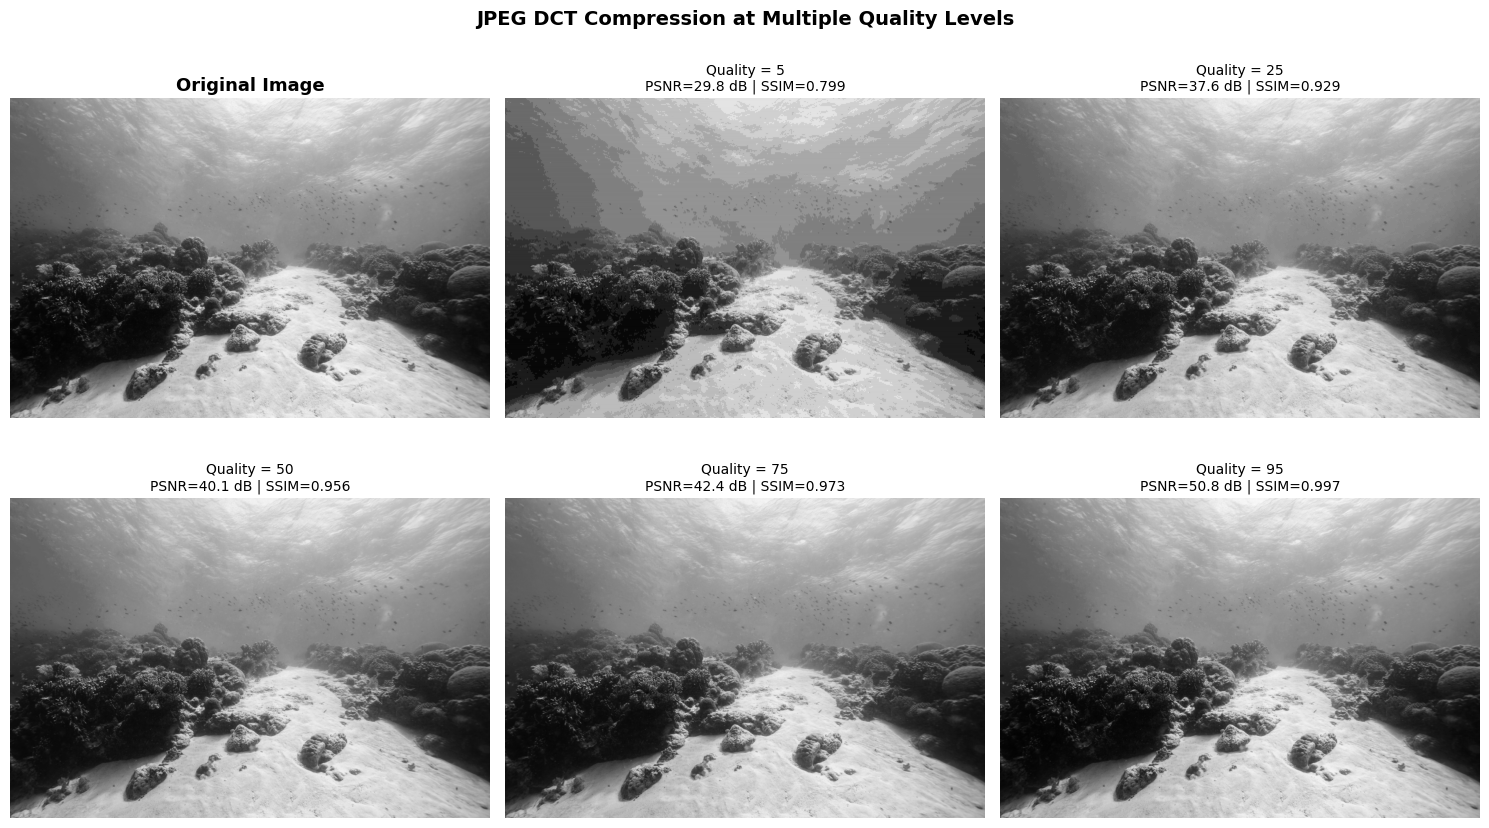

In [50]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

axes[0].imshow(image, cmap='gray')
axes[0].set_title("Original Image", fontsize=13, fontweight='bold')
axes[0].axis("off")

for idx, (q, comp, mse, psnr, ssim_score) in enumerate(results, start=1):
  axes[idx].imshow(comp, cmap='gray')
  axes[idx].set_title(
    f"Quality = {q}\nPSNR={psnr:.1f} dB | SSIM={ssim_score:.3f}",
    fontsize=10
  )
  axes[idx].axis("off")

plt.suptitle("JPEG DCT Compression at Multiple Quality Levels", fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig("compression_comparison.png", dpi=150)
plt.show()
# print(results)

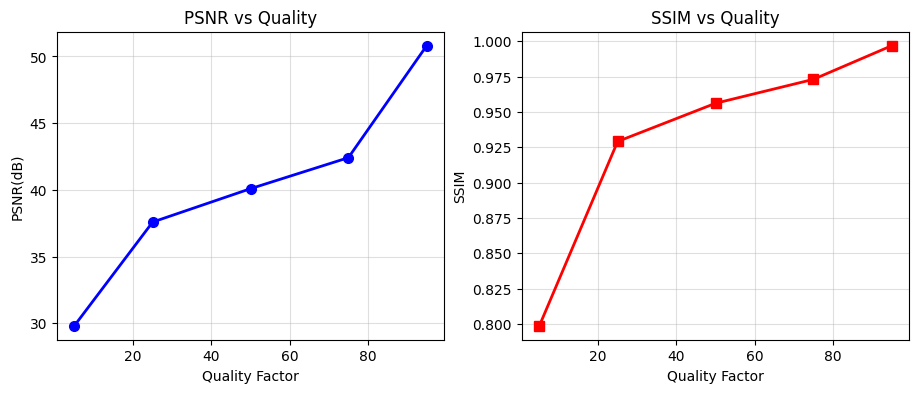

In [51]:
qs = [r[0] for r in results]
psnrs = [r[3] for r in results]
ssims = [r[4] for r in results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(qs, psnrs, 'bo-', linewidth=2, markersize=7)
ax1.set_xlabel("Quality Factor")
ax1.set_ylabel("PSNR(dB)")
ax1.set_title("PSNR vs Quality")
ax1.grid(True, alpha=0.4)

ax2.plot(qs, ssims, 'rs-', linewidth=2, markersize=7)
ax2.set_xlabel("Quality Factor")
ax2.set_ylabel("SSIM")
ax2.set_title("SSIM vs Quality")
ax2.grid(True, alpha=0.4)

<Figure size 640x480 with 0 Axes>

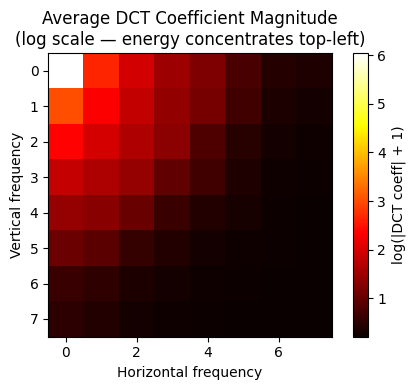

In [53]:
plt.suptitle("Image Quality Metrics vs Compression Quality Factor", fontsize=13)
plt.tight_layout()
# plt.savefig("metrics_vs_quality.png", dpi=150)
plt.show()

visualize_dct_coefficients(image)